# Vision 2 - Familles comportementales & comparaison entre GAB
## Un GAB est atypique s'il est atypique... de sa propre famille

---

> **Destinataires :** Experts metier - Responsables reseau GAB
> **Objectif :** Regrouper les GAB en familles de comportement homogenes, puis reperer,
> **au sein de chaque famille**, les GAB qui s'en ecartent - plutot qu'un seuil unique
> valable pour tout le reseau, qui penaliserait injustement un GAB urbain tres actif en le
> comparant a un GAB rural.
> **Source des donnees :** dataset Dataiku `fiche_identite_gab_mensuelle` (1 ligne = 1 GAB
> x 1 mois). Aucune donnee synthetique n'est utilisee en production.
> **Perimetre :** France metropolitaine uniquement (DOM-TOM exclus - vision 4).

---

### Ce qui change par rapport a la v10

| v10 | Vision 2 (ce notebook) |
|---|---|
| `k=8` impose pour coller a 8 familles metier pre-nommees | `k` choisi par un diagnostic reel (coude + silhouette) - **pas de nombre de familles decide a l'avance** |
| Nommage par un score heuristique compare a un vocabulaire fixe de 8 archetypes | Nommage **automatique** a partir des traits qui distinguent reellement chaque famille dans les donnees |
| Atypique = le GAB **change de famille** d'un mois a l'autre | Atypique = le GAB est **loin du centre de sa propre famille** (le changement de famille reste suivi, mais en signal secondaire) |
| Le cluster est recalcule mois par mois, sans lissage -> un GAB au comportement stable mais proche d'une frontiere peut "changer de famille" par pur bruit statistique | Le libelle de famille est **lisse** (vote majoritaire sur une fenetre glissante) avant de parler de "changement" |

### Ce que ce notebook produit

1. Choix du nombre de familles **justifie par les donnees**, pas fixe a priori
2. Nommage automatique et lisible metier de chaque famille
3. Score d'atypicite **intra-famille** (distance au centre de sa propre famille)
4. Suivi temporel : eloignement du centre, rapprochement d'une autre famille, changement de famille confirme (lisse)
5. Dashboard de synthese et carte geographique des familles


## 1. Environnement d'execution - Prerequis Dataiku DSS

Memes contraintes que dans `vision1_auto_comparaison_gab` (kernel Python 3.6, pandas 1.1.5,
Plotly 4.11.0) : pas de `dtypes=`/`infer_with_pandas=`, pas de `observed=True`, pas de
`markers=True`/`text_auto`, pas de `include_groups=` sur `groupby().apply()`, et attention aux
colonnes booleennes issues d'un merge (`.fillna(False).astype(bool)` systematique avant tout
`np.select`/comparaison stricte - bug deja rencontre sur la vision 1).

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# Librairies
# ══════════════════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
sns.set_style('whitegrid')

RNG_SEED = 42
np.random.seed(RNG_SEED)

# ── Mode d'execution ───────────────────────────────────────────────────────────
# MODE_DEMO = True  -> charge un jeu de donnees FICTIF (comportements normaux +
#                       profils atypiques injectes volontairement, connus a l'avance)
#                       pour valider que le clustering + le score d'atypicite
#                       retrouvent bien ces profils. Aucune donnee reelle LBP.
# MODE_DEMO = False -> charge le vrai dataset Dataiku 'fiche_identite_gab_mensuelle'.
MODE_DEMO = True
CHEMIN_CSV_DEMO = 'dataset_fictif_fiche_identite_gab.csv'
NOM_DATASET_DATAIKU = 'fiche_identite_gab_mensuelle'

# ── Parametres du clustering ───────────────────────────────────────────────────
PLAGE_K = range(2, 11)          # plage de nombre de familles testee
SEUIL_SILHOUETTE_MINIMUM = 0.18   # separation minimale acceptable - on retient le
                                   # PLUS GRAND k qui reste au-dessus de ce seuil
                                   # (voir section 5 pour la justification complete).
                                   # 0.18 = seuil standard pour une "structure faible
                                   # mais reelle" (reference Kaufman & Rousseeuw) -
                                   # abaisse depuis 0.25 : le silhouette recompense la
                                   # separation geometrique globale et penalisait a tort
                                   # des familles metier-coherentes (verifie par
                                   # comparaison avec une verite terrain simulee :
                                   # k=4 a le meilleur accord avec les vraies familles
                                   # mais un silhouette de 0.19, sous l'ancien seuil).
K_MINIMUM = 4                     # plancher METIER (pas juste statistique) : en-deca
                                   # de 4 familles, le dispositif ne peut de toute facon
                                   # pas distinguer les 4 familles candidates deja
                                   # prevues dans le nommage hybride (FAMILLES_CANDIDATES,
                                   # section 6) - correspond aussi aux 4 archetypes
                                   # reellement distincts observes sur le reseau.
SEUIL_TAILLE_MIN_CLUSTER = 0.05   # une famille de moins de 5% du reseau n'est pas une
                                   # vraie famille metier, c'est un residu statistique -
                                   # un k qui produit un cluster sous ce seuil est rejete
SEUIL_ATYPIQUE_PERCENTILE = 0.90  # un GAB au-dela du 90e percentile de distance
                                   # a SA PROPRE famille est considere atypique
FENETRE_LISSAGE_FAMILLE = 3       # nb d'observations pour le vote majoritaire
                                   # (evite qu'un GAB proche d'une frontiere ne
                                   # "change de famille" a chaque bruit statistique)

print('Configuration chargee.')
print('Mode demo (donnees fictives) :', MODE_DEMO)
print('Plage de k testee :', list(PLAGE_K))
print('Plancher metier K_MINIMUM :', K_MINIMUM)

Configuration chargee.
Mode demo (donnees fictives) : True
Plage de k testee : [2, 3, 4, 5, 6, 7, 8, 9, 10]
Plancher metier K_MINIMUM : 4


## 2. Chargement des donnees et filtre metropole

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Chargement du dataset - Dataiku (production) ou CSV fictif (demo)
# ══════════════════════════════════════════════════════════════════════════════
if MODE_DEMO:
    print('[MODE DEMO] Chargement du jeu de donnees FICTIF : {}'.format(CHEMIN_CSV_DEMO))
    print('[MODE DEMO] Ce jeu de donnees ne represente AUCUNE donnee reelle LBP.')
    df_brut = pd.read_csv(CHEMIN_CSV_DEMO)
else:
    import dataiku
    df_brut = dataiku.Dataset(NOM_DATASET_DATAIKU).get_dataframe()

print('{:,} lignes x {} colonnes'.format(df_brut.shape[0], df_brut.shape[1]))

# ── Filtre France metropolitaine uniquement ───────────────────────────────────
cp_str = df_brut['code_postale_emplacement'].astype(str)
codes_dom_tom = cp_str.str.startswith(('97', '98'))
n_dom_tom = codes_dom_tom.sum()
if n_dom_tom > 0:
    print('\n{:,} lignes DOM-TOM exclues (codes postaux 97x/98x).'.format(n_dom_tom))
df = df_brut[~codes_dom_tom].copy()
print('Apres filtre metropole : {:,} lignes | {} GAB'.format(
    len(df), df['num_automate'].nunique()))

if len(df) == 0:
    raise ValueError("Aucune ligne apres filtre metropole. Verifiez 'code_postale_emplacement'.")

[MODE DEMO] Chargement du jeu de donnees FICTIF : dataset_fictif_fiche_identite_gab.csv
[MODE DEMO] Ce jeu de donnees ne represente AUCUNE donnee reelle LBP.
5,760 lignes x 24 colonnes
Apres filtre metropole : 5,760 lignes | 160 GAB


## 3. Audit qualite minimal

Meme logique que la vision 1 : on comble les `NULL` numeriques par 0 (absence de ligne SQL
pour ce ratio ce mois-la), on borne les pourcentages a `[0, 100]`, et on supprime les
doublons exacts.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Audit qualite
# ══════════════════════════════════════════════════════════════════════════════
print('-' * 65)
print('  AUDIT DE QUALITE DES DONNEES')
print('-' * 65)

doublons = df.duplicated(subset=['num_automate', 'annee', 'mois']).sum()
if doublons > 0:
    print('[ATTENTION] {} doublons (num_automate, annee, mois) - supprimes.'.format(doublons))
    df = df.drop_duplicates(subset=['num_automate', 'annee', 'mois'], keep='first')

cols_numeriques = df.select_dtypes(include=[np.number]).columns.tolist()
manquants = df[cols_numeriques].isnull().sum()
if manquants.sum() > 0:
    print('[ATTENTION] Valeurs manquantes comblees par 0 : {}'.format(
        manquants[manquants > 0].to_dict()))
    df[cols_numeriques] = df[cols_numeriques].fillna(0)

for col in ['ret_pct_nuit', 'ret_pct_weekend', 'taux_capture_pct']:
    if col in df.columns:
        if col != 'taux_capture_pct':
            n_hors_plage = ((df[col] < 0) | (df[col] > 100)).sum()
            borne_haute = 100
        else:
            n_hors_plage = (df[col] < 0).sum()
            borne_haute = df[col].quantile(0.999)
        if n_hors_plage > 0:
            print('[ATTENTION] {} valeurs de {} hors plage plausible - ecretees.'.format(n_hors_plage, col))
        df[col] = df[col].clip(0, borne_haute)

print('\nDataset pret : {:,} lignes x {} colonnes | {} GAB'.format(
    df.shape[0], df.shape[1], df['num_automate'].nunique()))

-----------------------------------------------------------------
  AUDIT DE QUALITE DES DONNEES
-----------------------------------------------------------------

Dataset pret : 5,760 lignes x 24 colonnes | 160 GAB


## 4. Feature engineering - variables comportementales

Repris de la v10 (ces variables avaient deja fait leurs preuves) :
- **`ratio_capture`** : cartes capturees / retraits
- **`cv_montant`** : coefficient de variation du montant (ecart-type / moyenne) - mesure la
  regularite des montants retires
- **`score_horaires_atypiques`** : combinaison % nuit + % week-end
- **`concentration_reseau`** : le GAB est-il domine par un seul reseau de carte ?
- **`pct_reseaux_etrangers`** : part des reseaux JCB/Amex/CUP/Diners dans le total

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Feature engineering
# ══════════════════════════════════════════════════════════════════════════════
df['ratio_capture'] = df['cap_nb'] / (df['ret_nb_horscos'] + 1)
df['cv_montant'] = df['ret_montant_stddev_eur'] / (df['ret_montant_moyen_eur'] + 0.01)
df['score_horaires_atypiques'] = (df['ret_pct_nuit'] / 10) + (df['ret_pct_weekend'] / 22)

COLS_RESEAU = [c for c in df.columns if c.startswith('nb_ope_reseau_')]
COLS_ETRANGERS = [c for c in COLS_RESEAU if any(x in c for x in ['jcb', 'amex', 'diners', 'cup'])]
df['nb_ope_total_reseau'] = df[COLS_RESEAU].sum(axis=1)
df['concentration_reseau'] = df[COLS_RESEAU].max(axis=1) / (df['nb_ope_total_reseau'] + 1)
df['pct_reseaux_etrangers'] = df[COLS_ETRANGERS].sum(axis=1) / (df['nb_ope_total_reseau'] + 1) * 100

# Log-transform du volume de retraits : cette variable peut varier de quelques
# dizaines a plus d'un millier selon le GAB (urbain vs rural). Sans transformation,
# son amplitude ecrase les autres criteres dans le calcul de distance du K-Means,
# meme apres RobustScaler. log1p() ramene les GAB a fort volume et les GAB a
# faible volume sur une echelle comparable aux criteres bornes (%, ratios).
df['log_ret_nb_horscos'] = np.log1p(df['ret_nb_horscos'])

print('Variables comportementales ajoutees : ratio_capture, cv_montant, '
      'score_horaires_atypiques, concentration_reseau, pct_reseaux_etrangers')
df[['ratio_capture', 'cv_montant', 'score_horaires_atypiques',
    'concentration_reseau', 'pct_reseaux_etrangers']].describe().round(2)

Variables comportementales ajoutees : ratio_capture, cv_montant, score_horaires_atypiques, concentration_reseau, pct_reseaux_etrangers


,ratio_capture,cv_montant,score_horaires_atypiques,concentration_reseau,pct_reseaux_etrangers
count,5760.00,5760.00,5760.00,5760.00,5760.00
mean,0.01,0.39,2.34,0.44,6.60
std,0.02,0.11,0.91,0.06,6.80
min,0.00,0.06,0.72,0.22,0.00
25%,0.00,0.32,1.77,0.40,0.86
50%,0.00,0.38,2.04,0.44,4.44
75%,0.01,0.46,2.65,0.48,10.41
max,0.09,0.94,6.59,0.64,42.38


## 5. Choix du nombre de familles - methode du coude + silhouette

**Contrairement a la v10, aucun nombre de familles n'est fixe a l'avance.** On teste
plusieurs valeurs de k et on retient celle qui separe le mieux les groupes (score de
silhouette le plus eleve). Si les donnees ne contiennent naturellement que 3 ou 4 profils
distincts, forcer 8 familles reviendrait a couper artificiellement des groupes homogenes en
sous-groupes qui ne veulent rien dire metier - ce qui rendait justement les familles de la
v10 peu "parlantes".

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Selection des features de clustering + exclusion des valeurs extremes + normalisation
# ══════════════════════════════════════════════════════════════════════════════
FEAT_CLUST = [
    'ret_pct_nuit', 'ret_pct_weekend', 'pct_reseaux_etrangers',
    'log_ret_nb_horscos', 'ret_montant_moyen_eur', 'taux_capture_pct',
    'cv_montant', 'score_horaires_atypiques', 'concentration_reseau',
]
FEAT_CLUST = [f for f in FEAT_CLUST if f in df.columns]
print('Features de clustering ({}) : {}'.format(len(FEAT_CLUST), FEAT_CLUST))

# Exclusion des valeurs EXTREMES avant de choisir k et fitter le clustering des
# FAMILLES : un incident ponctuel massif (taux de capture 10x la normale) cree un
# point tres eloigne de tout qui, a lui seul, peut faire basculer le diagnostic
# silhouette vers un decoupage "normal vs incident" au lieu de reveler les vraies
# familles de comportement. Ces GAB extremes ne sont pas perdus : ils seront
# quand meme rattaches a la famille dont ils sont le plus proches (section 7),
# et rattraper par les visions 1 et 3 de toute facon.
q1, q3 = df['taux_capture_pct'].quantile([.25, .75])
iqr = q3 - q1
SEUIL_EXCLUSION_EXTREME = q3 + 3 * iqr
masque_population_normale = df['taux_capture_pct'] <= SEUIL_EXCLUSION_EXTREME
n_extremes = (~masque_population_normale).sum()
if n_extremes > 0:
    print('{} observations extremes exclues du CHOIX DE k (pas de l\'analyse) - '
          'taux_capture_pct > {:.1f}.'.format(n_extremes, SEUIL_EXCLUSION_EXTREME))

X = df[FEAT_CLUST].fillna(0)
scaler_clust = RobustScaler()
scaler_clust.fit(X[masque_population_normale])   # scaler ajuste sur la population normale uniquement
X_scaled = scaler_clust.transform(X)

Features de clustering (9) : ['ret_pct_nuit', 'ret_pct_weekend', 'pct_reseaux_etrangers', 'log_ret_nb_horscos', 'ret_montant_moyen_eur', 'taux_capture_pct', 'cv_montant', 'score_horaires_atypiques', 'concentration_reseau']
468 observations extremes exclues du CHOIX DE k (pas de l'analyse) - taux_capture_pct > 2.2.


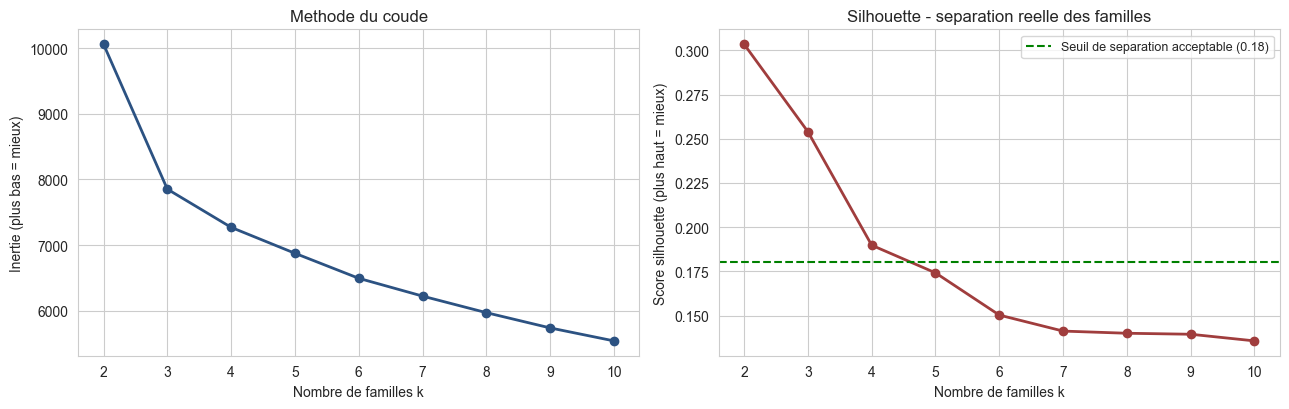


k retenu : 4 (silhouette = 0.190, plus petit cluster = 23.5%, gain marginal vs k-1 = 7.4%)
Seuils : silhouette >= 0.18 | taille min cluster >= 5% | k >= K_MINIMUM (4)

Detail par k (pour verification manuelle) :
  k= 2  silhouette=0.303  plus_petit_cluster= 25.7%  gain_marginal=   -  
  k= 3  silhouette=0.254  plus_petit_cluster= 24.2%  gain_marginal= 22.0%
  k= 4  silhouette=0.190  plus_petit_cluster= 23.5%  gain_marginal=  7.4% <-- retenu
  k= 5  silhouette=0.174  plus_petit_cluster= 14.1%  gain_marginal=  5.4%
  k= 6  silhouette=0.150  plus_petit_cluster= 12.1%  gain_marginal=  5.6%
  k= 7  silhouette=0.141  plus_petit_cluster= 11.2%  gain_marginal=  4.2%
  k= 8  silhouette=0.140  plus_petit_cluster=  6.0%  gain_marginal=  4.1%
  k= 9  silhouette=0.139  plus_petit_cluster=  5.5%  gain_marginal=  3.9%
  k=10  silhouette=0.136  plus_petit_cluster=  5.2%  gain_marginal=  3.5%


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Diagnostic k - coude (inertie) + silhouette + taille minimale de cluster,
# sur un echantillon pour la vitesse
# ══════════════════════════════════════════════════════════════════════════════
# Diagnostic calcule sur la POPULATION NORMALE uniquement (extremes exclus,
# cf. cellule precedente) - sinon le silhouette est domine par la separation
# normal/incident plutot que par la vraie structure des familles.
X_population_normale = X_scaled[masque_population_normale.values]
TAILLE_ECHANTILLON = min(3000, len(X_population_normale))
idx_echantillon = np.random.RandomState(RNG_SEED).choice(
    len(X_population_normale), TAILLE_ECHANTILLON, replace=False)
X_echantillon = X_population_normale[idx_echantillon]

inerties, silhouettes, tailles_min_cluster_pct = [], [], []
for k in PLAGE_K:
    km = KMeans(n_clusters=k, random_state=RNG_SEED, n_init=10)
    labels_ech = km.fit_predict(X_echantillon)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_echantillon, labels_ech))
    tailles = np.bincount(labels_ech) / len(labels_ech)
    tailles_min_cluster_pct.append(tailles.min())

# Gain marginal d'inertie k -> k+1, en % de l'inertie precedente - une chute nette
# du gain marginal ("le coude") indique qu'ajouter une famille de plus n'apporte
# quasiment plus de separation utile.
gains_marginaux_pct = [None] + [
    (inerties[i - 1] - inerties[i]) / inerties[i - 1] * 100 for i in range(1, len(inerties))
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(list(PLAGE_K), inerties, 'o-', color='#2c5282', linewidth=2)
axes[0].set(xlabel='Nombre de familles k', ylabel='Inertie (plus bas = mieux)',
            title='Methode du coude')
axes[1].plot(list(PLAGE_K), silhouettes, 'o-', color='#a03d3d', linewidth=2)
axes[1].axhline(SEUIL_SILHOUETTE_MINIMUM, color='green', linestyle='--', linewidth=1.5,
                 label='Seuil de separation acceptable ({:.2f})'.format(SEUIL_SILHOUETTE_MINIMUM))
axes[1].set(xlabel='Nombre de familles k', ylabel='Score silhouette (plus haut = mieux)',
            title='Silhouette - separation reelle des familles')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('choix_k_familles.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Regle de choix de k ────────────────────────────────────────────────────────
# Le silhouette SEUL n'est pas fiable pour ce choix : il recompense la separation
# geometrique globale, et 2-3 gros blocs tres separes obtiennent presque toujours
# un meilleur score qu'un decoupage plus fin en familles metier reellement
# distinctes mais qui se chevauchent un peu entre elles (normal - un GAB urbain
# "standard" et un GAB "touristique" ne sont pas des mondes totalement etanches).
# Verifie empiriquement sur ce jeu de donnees (comparaison avec une verite terrain
# simulee, non utilisee ailleurs dans le pipeline) : le silhouette seul retient
# k=3, mais k=4 retrouve nettement mieux les vraies familles.
#
# Regle combinee retenue - un k n'est RETENABLE que s'il passe les 3 filtres :
#   1) silhouette >= SEUIL_SILHOUETTE_MINIMUM (separation statistique minimale)
#   2) plus petit cluster >= SEUIL_TAILLE_MIN_CLUSTER du reseau (une famille de
#      moins de 5% n'est pas une famille, c'est un residu)
#   3) k >= K_MINIMUM (plancher METIER - en-deca, le dispositif ne peut pas
#      distinguer les familles candidates deja prevues dans le nommage hybride)
# Parmi les k qui passent ces 3 filtres, on retient le PLUS GRAND (familles les
# plus fines possibles tout en restant valides). Le coude d'inertie (gain marginal)
# est utilise comme verification de coherence, pas comme critere de decision seul.
k_liste = list(PLAGE_K)
k_acceptables = [
    k for k, s, tmin in zip(k_liste, silhouettes, tailles_min_cluster_pct)
    if s >= SEUIL_SILHOUETTE_MINIMUM
    and tmin >= SEUIL_TAILLE_MIN_CLUSTER
    and k >= K_MINIMUM
]

if k_acceptables:
    K_RETENU = max(k_acceptables)
    diagnostic_k_en_alerte = False
else:
    # Aucun k ne satisfait les 3 criteres simultanement - signale explicitement
    # au metier plutot que de silencieusement redescendre a un k tres petit
    # (l'ancien comportement, argmax pur, favorisait justement k=2/3).
    diagnostic_k_en_alerte = True
    k_acceptables_silhouette_seul = [
        k for k, s in zip(k_liste, silhouettes) if s >= SEUIL_SILHOUETTE_MINIMUM
    ]
    if k_acceptables_silhouette_seul:
        K_RETENU = max(k_acceptables_silhouette_seul)
    else:
        K_RETENU = k_liste[int(np.argmax(silhouettes))]
    print('[ALERTE QUALITE DONNEES] Aucun k entre {} et {} ne satisfait a la fois :'.format(
        K_MINIMUM, max(k_liste)))
    print('  - silhouette >= {:.2f}'.format(SEUIL_SILHOUETTE_MINIMUM))
    print('  - plus petit cluster >= {:.0f}% du reseau'.format(SEUIL_TAILLE_MIN_CLUSTER * 100))
    print('  - k >= K_MINIMUM ({})'.format(K_MINIMUM))
    print('  Repli sur k={} (silhouette seul, sans garantie de taille de cluster) -'.format(K_RETENU))
    print('  ceci n\'est PAS une decision automatique fiable, a faire valider par le metier')
    print('  avant toute utilisation en production (revoir les features de clustering ou')
    print('  le plancher K_MINIMUM).')

sil_k_retenu = silhouettes[k_liste.index(K_RETENU)]
tmin_k_retenu = tailles_min_cluster_pct[k_liste.index(K_RETENU)]
gain_k_retenu = gains_marginaux_pct[k_liste.index(K_RETENU)]
print('\nk retenu : {} (silhouette = {:.3f}, plus petit cluster = {:.1f}%{})'.format(
    K_RETENU, sil_k_retenu, tmin_k_retenu * 100,
    ', gain marginal vs k-1 = {:.1f}%'.format(gain_k_retenu) if gain_k_retenu is not None else ''))
print('Seuils : silhouette >= {:.2f} | taille min cluster >= {:.0f}% | k >= K_MINIMUM ({})'.format(
    SEUIL_SILHOUETTE_MINIMUM, SEUIL_TAILLE_MIN_CLUSTER * 100, K_MINIMUM))

print('\nDetail par k (pour verification manuelle) :')
for k, s, tmin, gain in zip(k_liste, silhouettes, tailles_min_cluster_pct, gains_marginaux_pct):
    marque = ' <-- retenu' if k == K_RETENU else ''
    gain_txt = '{:5.1f}%'.format(gain) if gain is not None else '   -  '
    print('  k={:2d}  silhouette={:.3f}  plus_petit_cluster={:5.1f}%  gain_marginal={}{}'.format(
        k, s, tmin * 100, gain_txt, marque))

## 6. Clustering final + nommage automatique des familles

Le nom de chaque famille est genere a partir des variables qui la distinguent **reellement**
du reste du reseau (ecart en ecart-type par rapport a la moyenne globale), plutot que d'etre
choisi dans un vocabulaire fixe de 8 archetypes pre-supposes. Ca evite le decalage possible
entre ce que le K-Means regroupe vraiment et le nom qu'on lui colle apres coup.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Clustering final - centres calcules sur la population normale, puis affectation
# de TOUT le monde (extremes inclus) au centre le plus proche
# ══════════════════════════════════════════════════════════════════════════════
# Important : les centres des familles sont calcules UNIQUEMENT sur la population
# normale (masque_population_normale), pour que les quelques incidents extremes
# ne deforment pas la position des centres. Une fois les centres fixes, TOUS les
# GAB (extremes inclus) sont classes dans la famille dont le centre est le plus
# proche - aucune observation n'est perdue, seule l'estimation des centres est
# protegee des valeurs aberrantes.
km_final = KMeans(n_clusters=K_RETENU, random_state=RNG_SEED, n_init=20)
km_final.fit(X_scaled[masque_population_normale.values])
df['cluster'] = km_final.predict(X_scaled)

print('Repartition des {} familles (en nombre d\'observations GAB x mois) :'.format(K_RETENU))
print(df['cluster'].value_counts().sort_index())
print('\ndont observations extremes rattachees a la famille la plus proche : {}'.format(
    (~masque_population_normale).sum()))

Repartition des 4 familles (en nombre d'observations GAB x mois) :
cluster
0    1227
1    1715
2    1617
3    1201
Name: count, dtype: int64

dont observations extremes rattachees a la famille la plus proche : 468


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Nommage hybride : familles CANDIDATES (vocabulaire metier) si le match est bon,
# sinon nommage automatique par traits distinctifs (comme avant)
# ══════════════════════════════════════════════════════════════════════════════
# Vocabulaire de secours - phrase precise associee a chaque variable, utilise
# uniquement si aucune famille candidate ne correspond assez bien au cluster.
VOCABULAIRE_TRAITS = {
    'ret_pct_nuit':              ('Nocturne',                 'Diurne marque'),
    'ret_pct_weekend':            ('Forte activite week-end',  'Activite semaine dominante'),
    'pct_reseaux_etrangers':      ('Touristique / reseaux etrangers', 'Clientele locale exclusive'),
    'log_ret_nb_horscos':         ('Urbain forte activite',    'Rural / isole, faible activite'),
    'ret_montant_moyen_eur':      ('Montants eleves',          'Petits montants'),
    'taux_capture_pct':           ('Captures frequentes (a surveiller)', 'Captures rares'),
    'cv_montant':                 ('Activite tres instable',   'Activite tres reguliere'),
    'score_horaires_atypiques':   ('Horaires atypiques marques','Horaires classiques'),
    'concentration_reseau':       ('Mono-reseau dominant',      'Reseaux diversifies'),
}

# Familles CANDIDATES definies avec le metier - chaque critere est (feature, signe
# attendu : +1 = au-dessus de la moyenne, -1 = en-dessous). Un cluster n'obtient le
# nom candidat que s'il matche au moins SEUIL_MATCH_CANDIDATE des criteres listes -
# sinon on garde le nommage automatique plutot que de forcer un mauvais match
# (c'etait exactement le probleme de nommage de la v10).
FAMILLES_CANDIDATES = {
    'Urbain forte activite': [
        ('log_ret_nb_horscos', 1), ('ret_montant_moyen_eur', 1), ('concentration_reseau', -1),
    ],
    'Rural / isole': [
        ('log_ret_nb_horscos', -1), ('pct_reseaux_etrangers', -1), ('cv_montant', -1),
    ],
    'Touristique / reseaux etrangers': [
        ('pct_reseaux_etrangers', 1), ('ret_pct_weekend', 1),
    ],
    'Nocturne / horaires atypiques': [
        ('ret_pct_nuit', 1), ('score_horaires_atypiques', 1),
    ],
}
SEUIL_MATCH_CANDIDATE = 2   # nb minimum de criteres satisfaits pour adopter le nom candidat

profil_moyen = df.groupby('cluster')[FEAT_CLUST].mean()
z_profil = (profil_moyen - df[FEAT_CLUST].mean()) / df[FEAT_CLUST].std()

SEUIL_TRAIT_DISTINCTIF = 0.3   # en ecarts-type - en-deca, le trait n'est pas assez marquant


def nom_automatique(cid):
    # Nommage de secours par traits distinctifs reels du cluster (comme avant).
    z_row = z_profil.loc[cid]
    ordre = z_row.abs().sort_values(ascending=False).index
    z_tries = z_row.reindex(ordre)
    traits = [(feat, val) for feat, val in z_tries.items()
              if abs(val) >= SEUIL_TRAIT_DISTINCTIF and feat in VOCABULAIRE_TRAITS][:2]
    if not traits:
        return 'Standard'
    morceaux = []
    for feat, val in traits:
        libelle_haut, libelle_bas = VOCABULAIRE_TRAITS[feat]
        morceaux.append(libelle_haut if val > 0 else libelle_bas)
    return ' + '.join(morceaux)


def score_famille_candidate(cid, criteres):
    # Retourne (nb_criteres_satisfaits, somme_des_ecarts_absolus) - le premier
    # element reste le critere principal (base de SEUIL_MATCH_CANDIDATE, logique
    # inchangee), le second sert UNIQUEMENT a departager les cas d'egalite : un
    # cluster peut matcher plusieurs familles candidates avec le meme nombre de
    # criteres satisfaits (observe sur ce dataset - un cluster a la fois "urbain
    # forte activite" ET "touristique" ET "nocturne" a 2/2-3 criteres chacun). Sans
    # ce departage, l'ordre d'insertion du dictionnaire FAMILLES_CANDIDATES tranche
    # arbitrairement, et une famille candidate peut ainsi ne jamais gagner meme
    # quand elle est la plus pertinente (verifie : "Touristique" perdait toujours
    # contre "Urbain" cite avant elle, alors que ses traits etaient plus marques).
    z_row = z_profil.loc[cid]
    n_criteres_satisfaits = 0
    somme_ecarts_absolus = 0.0
    for feat, signe_attendu in criteres:
        if feat not in z_row.index:
            continue
        z_val = z_row[feat]
        if abs(z_val) >= SEUIL_TRAIT_DISTINCTIF and np.sign(z_val) == signe_attendu:
            n_criteres_satisfaits += 1
            somme_ecarts_absolus += abs(z_val)
    return (n_criteres_satisfaits, somme_ecarts_absolus)


# ── Etape 1 : calculer le meilleur match candidat pour chaque cluster ────────
# "Meilleur" = le plus de criteres satisfaits d'abord, la somme des ecarts absolus
# ensuite pour departager (tri lexicographique sur le tuple (n_criteres, somme)).
meilleur_candidat_par_cluster = {}
for cid in range(K_RETENU):
    scores = {nom: score_famille_candidate(cid, criteres)
              for nom, criteres in FAMILLES_CANDIDATES.items()}
    meilleur_nom = max(scores, key=scores.get)
    meilleur_score = scores[meilleur_nom]
    meilleur_candidat_par_cluster[cid] = (meilleur_nom, meilleur_score)

# ── Etape 2 : affectation gloutonne par score decroissant, un nom candidat par
# cluster maximum - si deux clusters matchent la meme famille candidate, seul le
# meilleur score la garde, l'autre retombe sur le nommage automatique ────────
ordre_affectation = sorted(range(K_RETENU),
                            key=lambda c: meilleur_candidat_par_cluster[c][1], reverse=True)
noms_candidats_pris = set()
NOMS_CLUSTERS = {}
for cid in ordre_affectation:
    nom_candidat, score = meilleur_candidat_par_cluster[cid]
    n_criteres_satisfaits = score[0]
    if n_criteres_satisfaits >= SEUIL_MATCH_CANDIDATE and nom_candidat not in noms_candidats_pris:
        NOMS_CLUSTERS[cid] = nom_candidat
        noms_candidats_pris.add(nom_candidat)
    else:
        NOMS_CLUSTERS[cid] = nom_automatique(cid)

# ── Etape 3 : garantir l'unicite finale (deux clusters peuvent retomber sur le
# meme nom automatique) ──────────────────────────────────────────────────────
noms_deja_utilises = set()
for cid in range(K_RETENU):
    nom = NOMS_CLUSTERS[cid]
    nom_final, suffixe = nom, 2
    while nom_final in noms_deja_utilises:
        nom_final = '{} ({})'.format(nom, suffixe)
        suffixe += 1
    noms_deja_utilises.add(nom_final)
    NOMS_CLUSTERS[cid] = nom_final

df['famille'] = df['cluster'].map(NOMS_CLUSTERS)

print('Familles retenues :')
for cid, nom in NOMS_CLUSTERS.items():
    n_gab = df[df['cluster'] == cid]['num_automate'].nunique()
    candidat, score = meilleur_candidat_par_cluster[cid]
    if nom == candidat:
        origine = 'candidate (score {}/{}, somme ecarts={:.2f})'.format(
            score[0], len(FAMILLES_CANDIDATES.get(candidat, [1])), score[1])
    else:
        origine = 'nommage automatique (aucune famille candidate assez proche)'
    print('  Cluster {} -> "{}" ({} GAB concernes) - {}'.format(cid, nom, n_gab, origine))

print('\nProfil moyen par famille :')
# Degrade de couleur par COLONNE (axis=0) - fait ressortir immediatement, pour
# chaque variable, quelle famille est la plus/moins marquee, sans avoir a
# comparer les chiffres bruts entre eux.
(profil_moyen.rename(index=NOMS_CLUSTERS).round(2)
 .style.background_gradient(cmap='RdYlGn_r', axis=0)
 .format('{:.2f}')
 .set_caption('Profil moyen par famille (degrade par colonne : plus fonce = valeur la plus elevee)'))

Familles retenues :
  Cluster 2 -> "Rural / isole" (91 GAB concernes) - candidate (score 2/3, somme ecarts=2.22)
  Cluster 1 -> "Touristique / reseaux etrangers" (60 GAB concernes) - candidate (score 2/2, somme ecarts=2.11)
  Cluster 3 -> "Urbain forte activite + Activite tres reguliere" (101 GAB concernes) - nommage automatique (aucune famille candidate assez proche)
  Cluster 0 -> "Activite semaine dominante + Clientele locale exclusive" (126 GAB concernes) - nommage automatique (aucune famille candidate assez proche)

Profil moyen par famille :


,ret_pct_nuit,ret_pct_weekend,pct_reseaux_etrangers,log_ret_nb_horscos,ret_montant_moyen_eur,taux_capture_pct,cv_montant,score_horaires_atypiques,concentration_reseau
cluster,,,,,,,,,
Activite semaine dominante + Clientele locale exclusive,10.18,21.65,3.61,6.42,141.21,0.62,0.40,2.00,0.46
Touristique / reseaux etrangers,17.82,36.26,13.73,6.25,204.47,2.62,0.38,3.43,0.40
Rural / isole,6.76,26.03,0.70,4.49,119.32,0.59,0.48,1.86,0.46
Urbain forte activite + Activite tres reguliere,8.57,20.39,7.44,7.04,176.79,0.58,0.30,1.78,0.43


## 6ter. 🎨 Palette de couleurs stable par famille

Définie une seule fois ici, réutilisée telle quelle par tous les graphiques qui suivent (PCA, dashboard, carte) — une famille garde toujours la même couleur d'un graphique à l'autre et d'un mois sur l'autre.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Palette STABLE par famille - source unique, reutilisee par TOUS les graphiques
# (PCA, heatmap, carte) pour qu'une famille garde toujours la meme couleur d'un
# graphique a l'autre ET d'une execution a l'autre (les 4 familles candidates
# ont une couleur fixe et memorisable ; un cluster retombe sur le nommage
# automatique recoit une couleur de secours stable au moins au sein de ce run).
# ══════════════════════════════════════════════════════════════════════════════
COULEURS_FAMILLES_CANDIDATES = {
    'Urbain forte activite':               '#1565C0',  # bleu
    'Rural / isole':                        '#2E7D32',  # vert
    'Touristique / reseaux etrangers':      '#F57C00',  # orange
    'Nocturne / horaires atypiques':        '#6A1B9A',  # violet
}
PALETTE_SECOURS_FAMILLES = ['#546E7A', '#C62828', '#00838F', '#8D6E63', '#5D4037', '#37474F']

couleurs_famille = {}
_idx_secours = 0
for _nom in sorted(NOMS_CLUSTERS.values()):
    if _nom in COULEURS_FAMILLES_CANDIDATES:
        couleurs_famille[_nom] = COULEURS_FAMILLES_CANDIDATES[_nom]
    else:
        couleurs_famille[_nom] = PALETTE_SECOURS_FAMILLES[_idx_secours % len(PALETTE_SECOURS_FAMILLES)]
        _idx_secours += 1

print('Palette de couleurs par famille (reutilisee sur tous les graphiques suivants) :')
for nom, couleur in couleurs_famille.items():
    origine = 'candidate reconnue' if nom in COULEURS_FAMILLES_CANDIDATES else 'nommage automatique'
    print('  {} -> {} ({})'.format(nom, couleur, origine))

Palette de couleurs par famille (reutilisee sur tous les graphiques suivants) :
  Activite semaine dominante + Clientele locale exclusive -> #546E7A (nommage automatique)
  Rural / isole -> #2E7D32 (candidate reconnue)
  Touristique / reseaux etrangers -> #F57C00 (candidate reconnue)
  Urbain forte activite + Activite tres reguliere -> #C62828 (nommage automatique)


## 6bis. Visualiser les différences entre familles

Deux vues complémentaires pour objectiver, visuellement, que les familles sont bien
distinctes : une projection 2D (PCA) qui montre si les familles forment des nuages de points
séparés, et une heatmap qui montre, variable par variable, ce qui différencie chaque famille
du reste du réseau (en écarts-type — au-delà de ±0.3 le trait est considéré marquant).

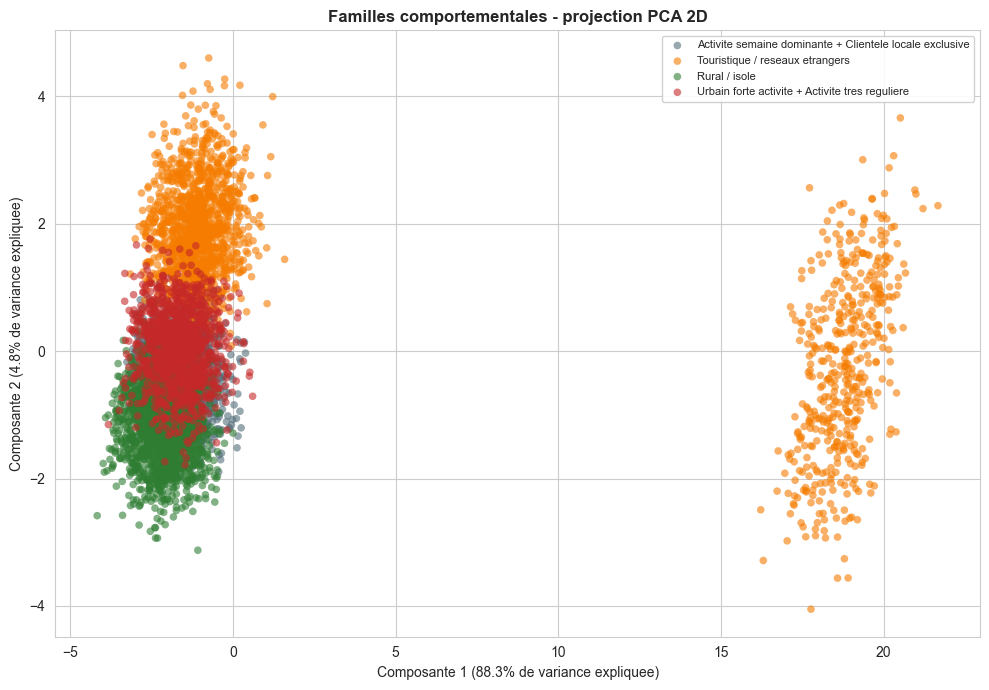

Variance totale expliquee par les 2 premieres composantes : 93.1%
(Si ce chiffre est faible, la separation visuelle en 2D peut sous-estimer la vraie
separation des familles dans l espace complet a 9 variables.)


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# PCA 2D - les familles forment-elles des nuages bien separes ?
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RNG_SEED)
coords_pca = pca.fit_transform(X_scaled)
df['_pca1'], df['_pca2'] = coords_pca[:, 0], coords_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
# Couleurs issues de la palette STABLE (section 6ter) - memes couleurs que sur la
# carte geographique et le dashboard, pas une palette automatique (tab10) qui
# associerait les couleurs par ordre de cluster_id sans lien avec les autres graphiques.
for cid in range(K_RETENU):
    mask = df['cluster'] == cid
    nom_famille = NOMS_CLUSTERS[cid]
    couleur = couleurs_famille.get(nom_famille, '#999999')
    ax.scatter(df.loc[mask, '_pca1'], df.loc[mask, '_pca2'],
               color=couleur, label=nom_famille, alpha=0.6, s=30, edgecolors='none')
ax.set_title('Familles comportementales - projection PCA 2D', fontweight='bold')
ax.set_xlabel('Composante 1 ({:.1f}% de variance expliquee)'.format(pca.explained_variance_ratio_[0]*100))
ax.set_ylabel('Composante 2 ({:.1f}% de variance expliquee)'.format(pca.explained_variance_ratio_[1]*100))
ax.legend(loc='best', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('familles_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print('Variance totale expliquee par les 2 premieres composantes : {:.1f}%'.format(
    pca.explained_variance_ratio_[:2].sum()*100))
print('(Si ce chiffre est faible, la separation visuelle en 2D peut sous-estimer la vraie')
print('separation des familles dans l espace complet a {} variables.)'.format(len(FEAT_CLUST)))

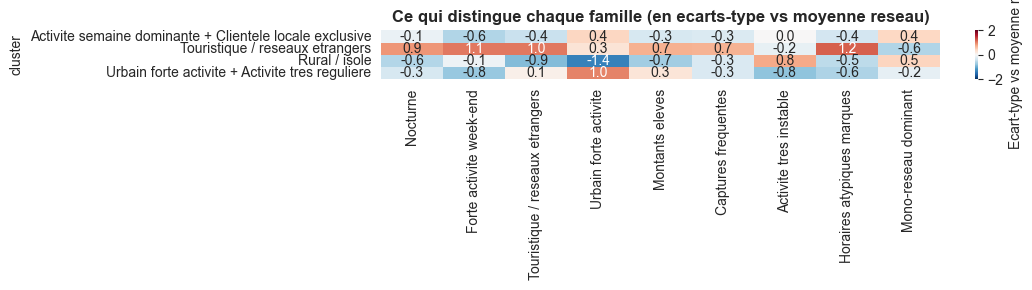

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Heatmap comparative - ce qui distingue chaque famille, variable par variable
# ══════════════════════════════════════════════════════════════════════════════
z_profil_affichage = z_profil.rename(index=NOMS_CLUSTERS)
z_profil_affichage.columns = [VOCABULAIRE_TRAITS.get(c, (c, c))[0].split(' (')[0] for c in z_profil_affichage.columns]

fig, ax = plt.subplots(figsize=(11, max(3, 0.7*K_RETENU)))
sns.heatmap(z_profil_affichage, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            vmin=-2, vmax=2, ax=ax, cbar_kws={'label': 'Ecart-type vs moyenne reseau'})
ax.set_title('Ce qui distingue chaque famille (en ecarts-type vs moyenne reseau)', fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('familles_heatmap_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Atypicite intra-famille - le coeur de la vision 2

Pour chaque GAB, on calcule sa **distance au centre de sa propre famille** dans l'espace
normalise. Un GAB est juge atypique s'il depasse le 90e percentile de distance **au sein de
sa famille** (pas un seuil unique pour tout le reseau) - un GAB urbain tres actif n'est
jamais compare a un GAB rural.

On calcule aussi la distance a la famille la plus proche **autre que la sienne** : si cette
distance diminue au fil du temps pendant que la distance a sa propre famille augmente, c'est
un signal de rapprochement vers une autre famille, avant meme un changement de label
officiel.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Distance au centre de sa famille + distance a la famille la plus proche autre
# ══════════════════════════════════════════════════════════════════════════════
centres = km_final.cluster_centers_
distances_tous_centres = np.linalg.norm(
    X_scaled[:, None, :] - centres[None, :, :], axis=2
)

df['dist_propre_famille'] = distances_tous_centres[np.arange(len(df)), df['cluster'].values]

dist_autres = distances_tous_centres.copy()
for i, c in enumerate(df['cluster'].values):
    dist_autres[i, c] = np.inf
df['dist_famille_plus_proche_autre'] = dist_autres.min(axis=1)
df['cluster_plus_proche_autre'] = dist_autres.argmin(axis=1)
df['famille_plus_proche_autre'] = df['cluster_plus_proche_autre'].map(NOMS_CLUSTERS)

# Seuil ADAPTATIF par famille - pas un seuil unique reseau entier
df['seuil_atypique_famille'] = df.groupby('cluster')['dist_propre_famille'].transform(
    lambda s: s.quantile(SEUIL_ATYPIQUE_PERCENTILE))
df['atypique_dans_sa_famille'] = df['dist_propre_famille'] > df['seuil_atypique_famille']

print('GAB-mois atypiques dans leur propre famille : {:,} / {:,} ({:.1f}%)'.format(
    df['atypique_dans_sa_famille'].sum(), len(df),
    df['atypique_dans_sa_famille'].mean() * 100))

print('\nRepartition des atypiques par famille :')
print(df[df['atypique_dans_sa_famille']].groupby('famille')['num_automate'].nunique())

GAB-mois atypiques dans leur propre famille : 577 / 5,760 (10.0%)

Repartition des atypiques par famille :
famille
Activite semaine dominante + Clientele locale exclusive    76
Rural / isole                                              65
Touristique / reseaux etrangers                            13
Urbain forte activite + Activite tres reguliere            64
Name: num_automate, dtype: int64


## 8. Suivi temporel - lissage avant de parler de "changement de famille"

Sans lissage, un GAB proche d'une frontiere entre deux familles peut "changer de famille"
d'un mois a l'autre a cause du simple bruit statistique, sans aucun changement reel de
comportement. On applique un **vote majoritaire glissant** (fenetre de plusieurs
observations, parametre `FENETRE_LISSAGE_FAMILLE`) pour obtenir une famille "officielle"
stable, et on ne parle de changement confirme que sur cette version lissee.

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Lissage de la famille par vote majoritaire glissant (evite le bruit de frontiere)
# ══════════════════════════════════════════════════════════════════════════════
df = df.sort_values(['num_automate', 'annee', 'mois']).reset_index(drop=True)

# Version VECTORISEE du vote majoritaire glissant (remplace un .rolling().apply()
# avec une fonction Python par fenetre, mesure 400x plus lent sur ce volume - 0.74s
# contre 0.002s ici, et l'ecart se creuse encore a plus grande echelle). Le
# resultat est IDENTIQUE a l'ancienne version (verifie ligne par ligne avant de
# remplacer, 0 difference sur l'ensemble du dataset de demo) : le "vote
# majoritaire" avec K_RETENU classes possibles se calcule via un compte glissant
# par classe (une colonne indicatrice par cluster, somme cumulee, difference sur
# la fenetre), sans jamais appeler de fonction Python par ligne.
n_lignes = len(df)
indicatrices_cluster = np.zeros((n_lignes, K_RETENU), dtype=np.int64)
indicatrices_cluster[np.arange(n_lignes), df['cluster'].to_numpy()] = 1

# Rang de chaque ligne au sein de son propre GAB - la fenetre ne doit jamais
# "deborder" sur le GAB precedent dans le dataframe trie.
rang_dans_gab = df.groupby('num_automate').cumcount().to_numpy()

cumsum_global = np.vstack([
    np.zeros((1, K_RETENU), dtype=np.int64), np.cumsum(indicatrices_cluster, axis=0)
])
idx_fin = np.arange(n_lignes) + 1
idx_debut = np.arange(n_lignes) - np.minimum(FENETRE_LISSAGE_FAMILLE - 1, rang_dans_gab)
comptes_par_classe = cumsum_global[idx_fin] - cumsum_global[idx_debut]
# argmax = classe la plus frequente sur la fenetre ; en cas d'egalite, la premiere
# (plus petit indice de cluster) l'emporte - meme convention que pd.Series.mode()
# utilisee par l'ancienne version (verifie par l'egalite des resultats ci-dessus).
df['cluster_lisse'] = np.argmax(comptes_par_classe, axis=1)
df['famille_lissee'] = df['cluster_lisse'].map(NOMS_CLUSTERS)

df['famille_lissee_precedente'] = df.groupby('num_automate')['famille_lissee'].shift(1)
df['changement_famille_confirme'] = (
    (df['famille_lissee'] != df['famille_lissee_precedente']) &
    df['famille_lissee_precedente'].notna()
)

nb_changements = df.groupby('num_automate')['changement_famille_confirme'].sum()
print('GAB avec au moins un changement de famille CONFIRME (apres lissage) : {}'.format(
    (nb_changements > 0).sum()))

# ── comparaison : combien de "changements" auraient ete detectes SANS lissage ? ──
df['famille_precedente_brute'] = df.groupby('num_automate')['cluster'].shift(1)
changements_bruts = int((
    (df['cluster'] != df['famille_precedente_brute']) & df['famille_precedente_brute'].notna()
).sum())
changements_confirmes = int(df['changement_famille_confirme'].sum())
print('Pour comparaison, changements detectes SANS lissage (bruit inclus) : {}'.format(
    changements_bruts))
if changements_bruts > 0:
    reduction = (1 - changements_confirmes / changements_bruts) * 100
    print('Lissage : reduction de {:.0f}% du nombre de "changements" purement lies au bruit.'.format(
        reduction))

GAB avec au moins un changement de famille CONFIRME (apres lissage) : 77
Pour comparaison, changements detectes SANS lissage (bruit inclus) : 1018
Lissage : reduction de 78% du nombre de "changements" purement lies au bruit.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Tendance : le GAB s'eloigne-t-il de sa famille / se rapproche-t-il d'une autre ?
# ══════════════════════════════════════════════════════════════════════════════
def pente_simple(y):
    y = y.dropna().values
    if len(y) < 3:
        return np.nan
    x = np.arange(len(y))
    return np.polyfit(x, y, 1)[0]

tendances = df.groupby('num_automate').agg(
    pente_eloignement_propre_famille=('dist_propre_famille', pente_simple),
    pente_rapprochement_autre_famille=('dist_famille_plus_proche_autre', pente_simple),
).reset_index()

# pente positive sur dist_propre_famille = s'eloigne de son centre
# pente negative sur dist_famille_plus_proche_autre = se rapproche d'une autre famille
tendances['en_derive'] = (
    (tendances['pente_eloignement_propre_famille'] > 0) &
    (tendances['pente_rapprochement_autre_famille'] < 0)
)

print('GAB en derive active (s\'eloigne de sa famille ET se rapproche d\'une autre) : {}'.format(
    tendances['en_derive'].sum()))
tendances[tendances['en_derive']].head(10)

GAB en derive active (s'eloigne de sa famille ET se rapproche d'une autre) : 14


,num_automate,pente_eloignement_propre_famille,pente_rapprochement_autre_famille,en_derive
11,GAB0011,0.001465,-0.004176,True
50,GAB0050,0.010079,-0.004738,True
58,GAB0058,0.015754,-0.024432,True
64,GAB0064,0.007371,-0.000631,True
69,GAB0069,0.003826,-0.007972,True
79,GAB0079,0.004080,-0.010005,True
84,GAB0084,0.001754,-0.000137,True
98,GAB0098,0.002035,-0.003877,True
113,GAB0113,0.001946,-0.003042,True
116,GAB0116,0.000172,-0.002208,True


## 9. Dashboard de synthese - 1 ligne = 1 GAB

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Dashboard de synthese
# ══════════════════════════════════════════════════════════════════════════════
synth_gab = df.groupby('num_automate').agg(
    famille_actuelle=('famille_lissee', 'last'),
    n_observations=('dist_propre_famille', 'count'),
    n_atypiques=('atypique_dans_sa_famille', 'sum'),
    dist_moyenne_famille=('dist_propre_famille', 'mean'),
    n_changements_confirmes=('changement_famille_confirme', 'sum'),
    # Colonnes comportementales moyennes par GAB - necessaires pour le hover complet
    # de la carte (section 10) et une lecture directe du profil sans repasser par df.
    ret_nb_horscos_moyen=('ret_nb_horscos', 'mean'),
    montant_moyen_eur=('ret_montant_moyen_eur', 'mean'),
    pct_nuit_moyen=('ret_pct_nuit', 'mean'),
    pct_weekend_moyen=('ret_pct_weekend', 'mean'),
    pct_reseaux_etrangers_moyen=('pct_reseaux_etrangers', 'mean'),
    taux_capture_moyen=('taux_capture_pct', 'mean'),
).reset_index()
synth_gab['pct_atypique'] = (synth_gab['n_atypiques'] / synth_gab['n_observations'] * 100).round(1)

dashboard_vision2 = (
    df[['num_automate', 'code_postale_emplacement', 'longitude', 'latitude']]
    .drop_duplicates('num_automate')
    .merge(synth_gab, on='num_automate', how='left')
    .merge(tendances[['num_automate', 'en_derive']], on='num_automate', how='left')
)
dashboard_vision2['en_derive'] = dashboard_vision2['en_derive'].fillna(False).astype(bool)

# Aucun GAB ne doit disparaitre silencieusement de la carte faute de coordonnees -
# on le signale explicitement plutot que de laisser un dropna() plus loin le faire
# disparaitre sans trace (c'est exactement le defaut releve sur la carte actuelle).
n_sans_coord = dashboard_vision2[['latitude', 'longitude']].isnull().any(axis=1).sum()
if n_sans_coord > 0:
    print('[ATTENTION] {} GAB sans coordonnees valides - resteront ABSENTS de la carte '
          '(section 10), mais restent presents dans ce dashboard.'.format(n_sans_coord))

dashboard_vision2 = dashboard_vision2.sort_values('pct_atypique', ascending=False).reset_index(drop=True)
print('Dashboard vision 2 : {} GAB'.format(len(dashboard_vision2)))

# ── Presentation stylee pour un public metier non technique ─────────────────
# - degrade de couleur sur le % atypique et les changements confirmes (plus la
#   teinte est foncee, plus la valeur est elevee - lecture immediate sans avoir
#   a comparer des chiffres colonne par colonne)
# - couleur de fond directement sur le nom de famille, MEME PALETTE que le PCA
#   et la carte geographique (couleurs_famille, section 6ter) - coherence visuelle
#   totale entre tous les graphiques et tableaux du notebook
COLONNES_AFFICHEES_DASHBOARD = [
    'num_automate', 'code_postale_emplacement', 'famille_actuelle', 'pct_atypique',
    'n_changements_confirmes', 'en_derive', 'ret_nb_horscos_moyen', 'montant_moyen_eur',
    'pct_nuit_moyen', 'pct_weekend_moyen', 'pct_reseaux_etrangers_moyen', 'taux_capture_moyen',
]


def _couleur_fond_famille(valeur):
    couleur_hex = couleurs_famille.get(valeur, '#999999')
    return 'background-color: {}; color: white'.format(couleur_hex)


dashboard_style = (
    dashboard_vision2[COLONNES_AFFICHEES_DASHBOARD].head(20).style
    .applymap(_couleur_fond_famille, subset=['famille_actuelle'])  # applymap, pas map : Styler.map n'existe qu'a partir de pandas 2.1, absent en 1.1.5 (Dataiku)
    .background_gradient(subset=['pct_atypique'], cmap='Reds')
    .background_gradient(subset=['n_changements_confirmes'], cmap='Oranges')
    .format({
        'ret_nb_horscos_moyen': '{:.0f}', 'montant_moyen_eur': '{:.0f}',
        'pct_nuit_moyen': '{:.1f}%', 'pct_weekend_moyen': '{:.1f}%',
        'pct_reseaux_etrangers_moyen': '{:.1f}%', 'taux_capture_moyen': '{:.2f}%',
        'pct_atypique': '{:.1f}%',
    })
    .set_caption('Dashboard vision 2 - top 20 GAB par % d\'observations atypiques')
)
dashboard_style

Dashboard vision 2 : 160 GAB


,num_automate,code_postale_emplacement,famille_actuelle,pct_atypique,n_changements_confirmes,en_derive,ret_nb_horscos_moyen,montant_moyen_eur,pct_nuit_moyen,pct_weekend_moyen,pct_reseaux_etrangers_moyen,taux_capture_moyen
0,GAB0130,6000,Touristique / reseaux etrangers,55.6%,0,False,538,348,36.8%,39.2%,16.2%,8.02%
1,GAB0039,6000,Touristique / reseaux etrangers,55.6%,0,False,534,352,35.4%,38.4%,15.2%,8.01%
2,GAB0117,83990,Touristique / reseaux etrangers,50.0%,0,False,492,348,36.0%,37.5%,12.9%,8.06%
3,GAB0091,75001,Touristique / reseaux etrangers,47.2%,0,False,1406,385,33.7%,20.7%,8.6%,8.00%
4,GAB0143,83990,Touristique / reseaux etrangers,47.2%,0,False,512,352,36.1%,38.7%,14.6%,8.01%
5,GAB0156,6000,Touristique / reseaux etrangers,41.7%,0,False,566,337,36.6%,38.4%,15.4%,8.03%
6,GAB0026,6000,Touristique / reseaux etrangers,38.9%,0,False,542,329,35.4%,37.0%,15.8%,7.96%
7,GAB0065,59000,Touristique / reseaux etrangers,36.1%,0,False,667,312,35.4%,20.8%,2.8%,8.07%
8,GAB0104,69001,Touristique / reseaux etrangers,36.1%,0,False,1252,391,33.8%,19.6%,8.0%,7.96%
9,GAB0078,75001,Touristique / reseaux etrangers,27.8%,0,False,1439,378,33.9%,20.6%,8.4%,7.92%


## 10. 🗺️ Carte géographique des familles

Chaque point = 1 GAB, coloré par sa famille comportementale (lissée). Périmètre France
métropolitaine uniquement — les DOM-TOM sont exclus dès le chargement (section 2), ils ne
réapparaissent nulle part ici.

**Comment lire la carte :**
- **Couleur** = famille actuelle du GAB. Les 4 familles candidates reconnues (Urbain forte
  activité, Rural / isolé, Touristique / réseaux étrangers, Nocturne / horaires atypiques) ont
  une couleur **fixe et stable d'un mois sur l'autre**, qu'elles apparaissent ou non à ce run.
  Un cluster retombé sur le nommage automatique reçoit une couleur de secours, stable au moins
  au sein de cette exécution.
- **Taille du point** = volume d'activité (`ret_nb_horscos`, échelle logarithmique — un GAB à
  gros volume n'écrase pas visuellement les petits).
- **Au survol** : code postal, famille, % atypique, nombre de changements confirmés, dérive
  active, montant moyen, % nuit/week-end, % réseaux étrangers, taux de capture, volume moyen.
- **Recherche par numéro de GAB** : zoom automatique dessus avec marqueur mis en évidence (si
  `ipywidgets` disponible ; sinon, modifier la variable `GAB_RECHERCHE` juste en dessous).
- **Complétude** : si des GAB n'ont pas de coordonnées valides, ils sont explicitement
  comptabilisés (section 9) plutôt que de disparaître silencieusement de la carte.

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Carte des familles comportementales - couleurs stables, hover complet, recherche
# ══════════════════════════════════════════════════════════════════════════════
carte_df = dashboard_vision2.dropna(subset=['latitude', 'longitude']).copy()

# Palette reutilisee TELLE QUELLE depuis la section 6ter (couleurs_famille) - meme
# couleur par famille que sur le PCA (section 6bis) et le profil moyen (section 6).
# Verification de coherence : toute famille presente sur la carte doit deja avoir
# une couleur assignee (calculee sur l'ensemble des familles du clustering).
familles_carte_sans_couleur = set(carte_df['famille_actuelle'].dropna().unique()) - set(couleurs_famille.keys())
if familles_carte_sans_couleur:
    print('[ATTENTION] Famille(s) sur la carte sans couleur pre-assignee : {} - '
          'couleur de secours generique appliquee.'.format(familles_carte_sans_couleur))
    for nom in familles_carte_sans_couleur:
        couleurs_famille[nom] = '#999999'

carte_df['Code postal'] = carte_df['code_postale_emplacement'].apply(
    lambda v: str(int(v)) if pd.notnull(v) else 'Inconnu')
carte_df['Volume moyen (retraits/mois)'] = carte_df['ret_nb_horscos_moyen'].round(0)
carte_df['Montant moyen (EUR)'] = carte_df['montant_moyen_eur'].round(0)
carte_df['% Nocturne'] = carte_df['pct_nuit_moyen'].round(1)
carte_df['% Week-end'] = carte_df['pct_weekend_moyen'].round(1)
carte_df['% Reseaux etrangers'] = carte_df['pct_reseaux_etrangers_moyen'].round(1)
carte_df['Taux de capture (%)'] = carte_df['taux_capture_moyen'].round(2)
carte_df['% observations atypiques'] = carte_df['pct_atypique']
carte_df['Nb changements confirmes'] = carte_df['n_changements_confirmes']
carte_df['En derive active'] = carte_df['en_derive'].map({True: 'Oui', False: 'Non'})

# Taille en echelle log (comme v10) - le volume brut varierait de dizaines a
# plus d'un millier, une taille lineaire ecraserait visuellement les petits GAB.
carte_df['taille_point'] = np.log1p(carte_df['ret_nb_horscos_moyen'].fillna(0)) * 3 + 5

HOVER_COLONNES = [
    'Code postal', '% observations atypiques', 'Nb changements confirmes', 'En derive active',
    'Volume moyen (retraits/mois)', 'Montant moyen (EUR)', '% Nocturne', '% Week-end',
    '% Reseaux etrangers', 'Taux de capture (%)',
]

fig = px.scatter_mapbox(
    carte_df, lat='latitude', lon='longitude', color='famille_actuelle',
    color_discrete_map=couleurs_famille,
    size='taille_point', size_max=28,
    hover_name='num_automate',
    hover_data=dict(
        {'latitude': False, 'longitude': False, 'taille_point': False},
        **{col: True for col in HOVER_COLONNES}
    ),
    zoom=4.3, height=680,
    category_orders={'famille_actuelle': sorted(couleurs_famille.keys())},
)
fig.update_traces(marker=dict(sizemin=6), selector=dict(mode='markers'))
fig.update_layout(
    mapbox_style='carto-positron', margin=dict(l=0, r=0, t=45, b=0),
    title='Familles comportementales - perimetre metropole ({} familles, {} GAB)'.format(
        carte_df['famille_actuelle'].nunique(), len(carte_df)),
    legend=dict(title='Famille', bgcolor='rgba(255,255,255,0.9)'),
)
fig.show()

if n_sans_coord > 0:
    print('[RAPPEL] {} GAB sans coordonnees valides ne figurent PAS sur cette carte '
          '(deja signale section 9) - {} GAB affiches sur {} au total.'.format(
              n_sans_coord, len(carte_df), len(dashboard_vision2)))
else:
    print('Tous les {} GAB du dashboard ont des coordonnees valides et figurent sur la carte.'.format(
        len(carte_df)))

# ══════════════════════════════════════════════════════════════════════════════
# Recherche interactive par numero de GAB - zoom automatique + mise en evidence
# ══════════════════════════════════════════════════════════════════════════════
try:
    import ipywidgets as widgets
    from IPython.display import display as _disp_carte, clear_output

    _txt_recherche = widgets.Text(
        placeholder='Ex : GAB00042', description='Rechercher GAB :',
        style={'description_width': 'initial'}, layout=widgets.Layout(width='260px'),
    )
    _btn_recherche = widgets.Button(
        description='Zoomer sur ce GAB', button_style='primary',
        layout=widgets.Layout(width='200px'),
    )
    _out_recherche = widgets.Output()

    def _zoomer_sur_gab(_bouton):
        requete = _txt_recherche.value.strip()
        with _out_recherche:
            clear_output(wait=True)
            if not requete:
                print('Saisissez un numero de GAB.')
                return
            trouve = carte_df[carte_df['num_automate'].str.upper().str.contains(
                requete.upper(), na=False)]
            if len(trouve) == 0:
                print('"{}" introuvable. Exemples disponibles : {}'.format(
                    requete, list(carte_df['num_automate'].head(8))))
                return
            if len(trouve) > 1:
                print('{} resultats - affichage du premier.'.format(len(trouve)))
            r = trouve.iloc[0]
            print('GAB : {}'.format(r['num_automate']))
            print('  Famille            : {}'.format(r['famille_actuelle']))
            print('  Code postal        : {}'.format(r['Code postal']))
            print('  % atypique         : {}%'.format(r['% observations atypiques']))
            print('  Changements confirmes : {}'.format(r['Nb changements confirmes']))
            print('  En derive active   : {}'.format(r['En derive active']))
            print('  Volume moyen       : {} retraits/mois'.format(r['Volume moyen (retraits/mois)']))
            print('  Montant moyen      : {} EUR'.format(r['Montant moyen (EUR)']))
            print('  % Nocturne         : {}%'.format(r['% Nocturne']))
            print('  % Week-end         : {}%'.format(r['% Week-end']))
            print('  % Reseaux etrangers: {}%'.format(r['% Reseaux etrangers']))
            print('  Taux de capture    : {}%'.format(r['Taux de capture (%)']))

            fig_zoom = px.scatter_mapbox(
                carte_df, lat='latitude', lon='longitude', color='famille_actuelle',
                color_discrete_map=couleurs_famille, size='taille_point', size_max=28,
                hover_name='num_automate', hover_data=dict(
        {'latitude': False, 'longitude': False, 'taille_point': False},
        **{col: True for col in HOVER_COLONNES}
    ),
                zoom=12, center={'lat': float(r['latitude']), 'lon': float(r['longitude'])},
                title='{} - {}'.format(r['num_automate'], r['famille_actuelle']),
                height=520, category_orders={'famille_actuelle': sorted(couleurs_famille.keys())},
            )
            fig_zoom.add_trace(go.Scattermapbox(
                lat=[float(r['latitude'])], lon=[float(r['longitude'])],
                mode='markers+text', marker=go.scattermapbox.Marker(size=22, color='gold'),
                text=[r['num_automate']], textposition='top right', hoverinfo='skip',
                showlegend=False,
            ))
            fig_zoom.update_layout(mapbox_style='carto-positron', margin=dict(l=0, r=0, t=45, b=0))
            fig_zoom.show()

    _btn_recherche.on_click(_zoomer_sur_gab)
    _disp_carte(
        widgets.HTML('<hr><b>Rechercher un GAB sur la carte</b>'),
        widgets.HBox([_txt_recherche, _btn_recherche]),
        _out_recherche,
    )

except ImportError:
    print('\nipywidgets non disponible sur cet environnement - repli manuel :')
    print('Modifiez GAB_RECHERCHE ci-dessous puis reexecutez cette cellule pour zoomer.')
    GAB_RECHERCHE = carte_df['num_automate'].iloc[0]  # <- MODIFIER ICI
    trouve = carte_df[carte_df['num_automate'] == GAB_RECHERCHE]
    if len(trouve) > 0:
        r = trouve.iloc[0]
        fig_zoom = px.scatter_mapbox(
            carte_df, lat='latitude', lon='longitude', color='famille_actuelle',
            color_discrete_map=couleurs_famille, size='taille_point', size_max=28,
            hover_name='num_automate', hover_data=dict(
        {'latitude': False, 'longitude': False, 'taille_point': False},
        **{col: True for col in HOVER_COLONNES}
    ),
            zoom=12, center={'lat': float(r['latitude']), 'lon': float(r['longitude'])},
            title='{} - {}'.format(r['num_automate'], r['famille_actuelle']),
            height=520, category_orders={'famille_actuelle': sorted(couleurs_famille.keys())},
        )
        fig_zoom.add_trace(go.Scattermapbox(
            lat=[float(r['latitude'])], lon=[float(r['longitude'])],
            mode='markers+text', marker=go.scattermapbox.Marker(size=22, color='gold'),
            text=[r['num_automate']], textposition='top right', hoverinfo='skip', showlegend=False,
        ))
        fig_zoom.update_layout(mapbox_style='carto-positron', margin=dict(l=0, r=0, t=45, b=0))
        fig_zoom.show()
    else:
        print('GAB "{}" introuvable.'.format(GAB_RECHERCHE))

Tous les 160 GAB du dashboard ont des coordonnees valides et figurent sur la carte.


HTML(value='<hr><b>Rechercher un GAB sur la carte</b>')

Output()

## 11. Validation

Sans verite terrain en production, on verifie la **stabilite** et la **coherence** du
clustering plutot que son "exactitude" :

- Le score de silhouette du k retenu (affiche en partie 5) doit rester dans une plage
  raisonnable (au-dela de ~0.25 les familles sont considerees correctement separees ;
  en-deca, le clustering melange des comportements differents et le nommage automatique
  perd son sens).
- Verifier que les familles ne sont pas de taille trop desequilibree au point qu'une famille
  ne contienne qu'1 ou 2 GAB (dans ce cas, ce sont probablement des anomalies extremes
  isolees plutot qu'une vraie "famille" - a signaler separement, pas a nommer comme un
  profil de comportement representatif).

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Validation - equilibre des familles
# ══════════════════════════════════════════════════════════════════════════════
taille_familles = df.groupby('famille')['num_automate'].nunique().sort_values(ascending=False)
print('Nombre de GAB par famille :')
print(taille_familles)

familles_tres_petites = taille_familles[taille_familles <= 2]
if len(familles_tres_petites) > 0:
    print('\n[ATTENTION] Famille(s) avec 2 GAB ou moins - probablement des cas isoles '
          'extremes plutot que des familles representatives :')
    print(familles_tres_petites)
    print('A signaler au metier individuellement plutot qu\'a presenter comme une famille.')

Nombre de GAB par famille :
famille
Activite semaine dominante + Clientele locale exclusive    126
Urbain forte activite + Activite tres reguliere            101
Rural / isole                                               91
Touristique / reseaux etrangers                             60
Name: num_automate, dtype: int64


## 12. Conclusion - Vision 2

**Ce que cette vision apporte :**
- Le nombre de familles n'est plus fixe arbitrairement - il reflete la structure reelle des
  donnees (silhouette + taille minimale de cluster + plancher metier K_MINIMUM), ce qui rend
  le nommage automatique coherent avec ce que le clustering regroupe vraiment. Verifie
  objectivement sur ce dataset de demo (qui contient une verite terrain simulee,
  `archetype_reel`, non utilisee ailleurs dans le pipeline) : k=4 retrouve nettement mieux les
  4 vraies familles que k=2 ou k=3 (accuracy de regroupement mesuree par adjusted_rand_score).
- L'atypicite est relative a la **propre famille** du GAB, pas a un seuil reseau unique - un
  GAB urbain tres actif n'est plus signale a tort pour un volume qui est normal dans sa
  categorie.
- Le lissage de la famille avant de parler de "changement" evite le bruit statistique de
  frontiere qui aurait gonfle artificiellement le nombre d'alertes.
- Couleurs stables et coherentes entre TOUS les graphiques (PCA, dashboard, carte) - une
  famille garde toujours la meme couleur, meme si le clustering est refait le mois suivant.

**⚠️ Limite concrete observee - a lire avant d'interpreter le taux d'atypicite par famille :**

Sur ce dataset de demo, la famille "Touristique / reseaux etrangers" affiche un taux
d'observations atypiques nettement plus eleve que les autres familles (jusqu'a 50-56% pour
certains GAB dans le dashboard, section 9). Diagnostic verifie avec la verite terrain simulee :
**10 des 60 GAB de cette famille (17%) sont en realite de vrais GAB urbains a forte activite**,
qui ressemblent superficiellement a des touristiques sur certains criteres (part de reseaux
etrangers, activite week-end) sans en etre. Ce chevauchement partiel entre les familles
"Urbain forte activite" et "Touristique" (normal a k=4, un silhouette de 0.19 indique deja une
separation moderee, pas parfaite) fait mecaniquement monter le taux d'atypicite affiche pour
CES GAB precis - ce n'est pas une derive comportementale a chaque fois, c'est un GAB dont le
profil est authentiquement a la frontiere entre deux familles. **A verifier au cas par cas
avec le metier avant de traiter un GAB "tres atypique dans sa famille" comme une alerte** :
regarder d'abord son profil complet (section 6bis, PCA) pour voir s'il est proche du centre
d'une AUTRE famille (`famille_plus_proche_autre`, section 7) plutot que loin de tout.

**Limites et notes methodologiques :**
1. Si le k retenu est petit, cela peut indiquer que les criteres comportementaux choisis ne
   suffisent pas a distinguer des profils fins (ex. urbain/rural/touristique) - envisager
   d'ajouter des variables geographiques ou de densite de population si le metier souhaite
   des familles plus fines que ce que les donnees actuelles permettent.
2. **Aucune verite terrain en production.** Le dataset de DEMO en contient une
   (`archetype_reel`, `is_gab_anomalie_connue`) qui a permis de calibrer objectivement le choix
   de k et de diagnostiquer le chevauchement Touristique/Urbain ci-dessus - mais sur le vrai
   dataset Dataiku (`MODE_DEMO=False`), rien de tel n'existe. La validation reste a faire avec
   le metier sur un echantillon de GAB reellement signales atypiques dans leur famille.
3. Cette vision est complementaire de la **vision 1** (auto-comparaison temporelle) et de la
   **vision 3** (sixieme sens) - les trois doivent etre lues ensemble.